# Monte Carlo Portfolio Simulation

This notebook generates thousands of random portfolio allocations to explore the feasible risk-return space.

For each simulated portfolio, we calculate:
- expected annual return,
- annual volatility,
- Sharpe ratio.

The simulation provides an intuitive visualization of the risk-return trade-off and the efficient frontier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"]

returns = prices.pct_change().dropna()

mu = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [3]:
n_assets = len(tickers)

random_weights = np.random.random(n_assets)

random_weights

array([0.10383274, 0.59425598, 0.98013002, 0.3210938 , 0.01413894,
       0.75642264, 0.17835864, 0.64017977])

In [4]:
random_weights.sum()

np.float64(3.5884125169873506)

In [5]:
random_weights = random_weights / random_weights.sum()

random_weights

array([0.02893556, 0.16560414, 0.2731375 , 0.08948074, 0.00394016,
       0.2107959 , 0.04970405, 0.17840194])

In [6]:
random_weights.sum()

np.float64(0.9999999999999999)

In [8]:
risk_free_rate = 0
random_return = random_weights @ mu

random_variance = (
    random_weights
    @ cov_matrix
    @ random_weights
)

random_volatility = np.sqrt(random_variance)

random_sharpe = (
    random_return - risk_free_rate
) / random_volatility

In [9]:
print(f"Return: {random_return:.2%}")
print(f"Volatility: {random_volatility:.2%}")
print(f"Sharpe: {random_sharpe:.2f}")

Return: 17.27%
Volatility: 16.87%
Sharpe: 1.02


## Simulating Random Portfolios

We generate 10,000 long-only portfolios.

For each portfolio, random positive weights are generated and normalized so that the portfolio weights sum to one.

In [10]:
n_portfolios = 10000

portfolio_returns = np.zeros(n_portfolios)
portfolio_volatilities = np.zeros(n_portfolios)
portfolio_sharpes = np.zeros(n_portfolios)

all_weights = np.zeros((n_portfolios, n_assets))

In [11]:
for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights = weights / weights.sum()
    
    portfolio_return = weights @ mu

    portfolio_variance = (
        weights
        @ cov_matrix
        @ weights
    )

    portfolio_volatility = np.sqrt(portfolio_variance)

    portfolio_sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    portfolio_returns[i] = portfolio_return
    portfolio_volatilities[i] = portfolio_volatility
    portfolio_sharpes[i] = portfolio_sharpe

    all_weights[i] = weights

In [12]:
simulation_results = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe": portfolio_sharpes
})

simulation_results.head()

,Return,Volatility,Sharpe
0,0.190026,0.177162,1.072610
1,0.190875,0.185821,1.027197
2,0.202601,0.174802,1.159036
3,0.217311,0.187491,1.159047
4,0.189580,0.172167,1.101138


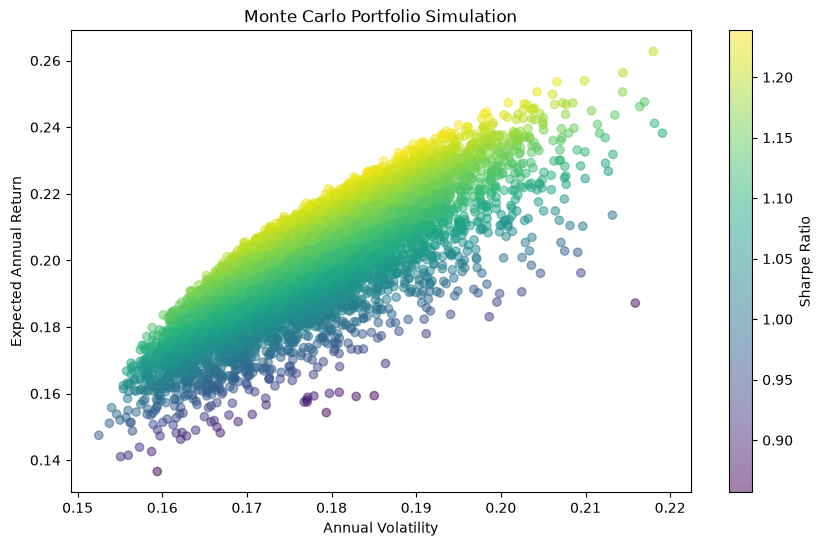

In [13]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpes,
    alpha=0.5
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")

plt.show()

In [15]:
max_sharpe_index = np.argmax(portfolio_sharpes)
max_sharpe_return = portfolio_returns[max_sharpe_index]
max_sharpe_volatility = portfolio_volatilities[max_sharpe_index]
max_sharpe_weights = all_weights[max_sharpe_index]
print(f"Return: {max_sharpe_return:.2%}")
print(f"Volatility: {max_sharpe_volatility:.2%}")
print(f"Sharpe: {portfolio_sharpes[max_sharpe_index]:.2f}")

Return: 23.49%
Volatility: 18.97%
Sharpe: 1.24


In [16]:
pd.Series(
    max_sharpe_weights,
    index=tickers
).sort_values(ascending=False)

MSFT    0.257915
PG      0.228090
AAPL    0.217018
XOM     0.134501
JPM     0.107720
JNJ     0.048672
CAT     0.005421
NEE     0.000664
dtype: float64

In [17]:
min_vol_index = np.argmin(portfolio_volatilities)
min_vol_return = portfolio_returns[min_vol_index]
min_volatility = portfolio_volatilities[min_vol_index]
min_vol_weights = all_weights[min_vol_index]
print(f"Return: {min_vol_return:.2%}")
print(f"Volatility: {min_volatility:.2%}")
print(f"Sharpe: {portfolio_sharpes[min_vol_index]:.2f}")

Return: 14.74%
Volatility: 15.25%
Sharpe: 0.97


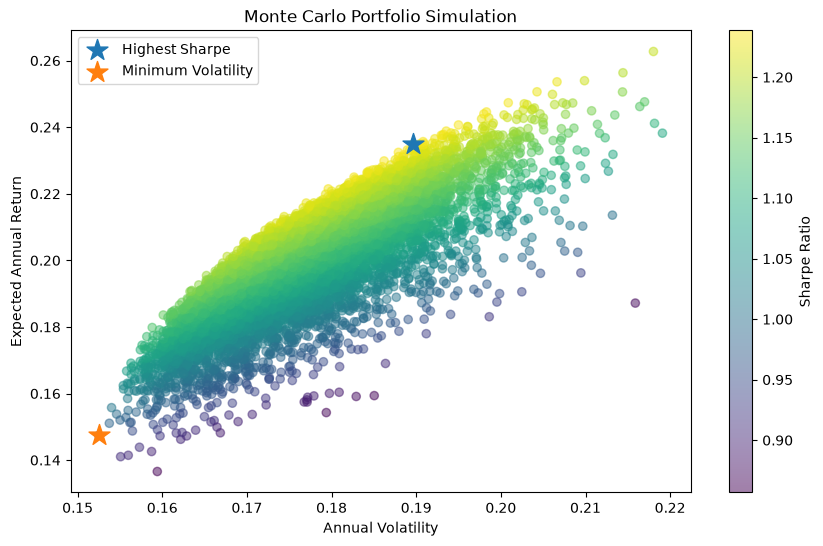

In [18]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpes,
    alpha=0.5
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Highest Sharpe"
)

plt.scatter(
    min_volatility,
    min_vol_return,
    marker="*",
    s=250,
    label="Minimum Volatility"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()

plt.show()